<a href="https://colab.research.google.com/github/lokya-1907/231FA04F97-MLOps-Feast-SkillGap/blob/main/MLops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q feast==0.53.0 pandas pyarrow scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.7/431.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [2]:
import os
import pandas as pd
from pathlib import Path

In [3]:
%cd /content

!mkdir -p feature_repo/data
%cd /content/feature_repo

/content
/content/feature_repo


In [4]:
from google.colab import files

uploaded = files.upload()

Saving curriculum_industry_skill_gap.csv to curriculum_industry_skill_gap.csv


In [5]:
uploaded_file = list(uploaded.keys())[0]

if uploaded_file != "curriculum_industry_skill_gap.csv":
    os.rename(
        uploaded_file,
        "curriculum_industry_skill_gap.csv"
    )

print("Dataset uploaded successfully")

Dataset uploaded successfully


In [6]:
df = pd.read_csv("curriculum_industry_skill_gap.csv")

print(df.shape)
display(df.head())
print(df.columns.tolist())

(80, 18)


,student_id,event_timestamp,curriculum_track,python_curriculum,python_industry,sql_curriculum,sql_industry,ml_curriculum,ml_industry,cloud_curriculum,cloud_industry,communication_curriculum,communication_industry,internship_months,projects_completed,certification_count,industry_experience_months,target_readiness
0,S001,2026-01-05 13:18:00,Data Science,1,1,2,1,2,1,1,2,3,1,0,1,1,14,0
1,S002,2026-01-08 15:30:00,Cloud Computing,2,3,3,2,3,4,2,1,2,2,5,4,1,13,0
2,S003,2026-01-11 11:30:00,Artificial Intelligence,3,1,5,3,4,4,4,2,5,5,1,6,0,35,0
3,S004,2026-01-14 12:01:00,Software Engineering,4,2,3,2,4,2,4,2,5,5,7,5,1,23,0
4,S005,2026-01-17 16:00:00,Data Science,3,1,3,4,3,2,4,4,3,4,3,5,0,14,0


['student_id', 'event_timestamp', 'curriculum_track', 'python_curriculum', 'python_industry', 'sql_curriculum', 'sql_industry', 'ml_curriculum', 'ml_industry', 'cloud_curriculum', 'cloud_industry', 'communication_curriculum', 'communication_industry', 'internship_months', 'projects_completed', 'certification_count', 'industry_experience_months', 'target_readiness']


In [7]:
%%writefile prepare_data.py

from pathlib import Path
import pandas as pd


INPUT_FILE = "curriculum_industry_skill_gap.csv"
OUTPUT_FILE = "data/skill_gap_features.parquet"


def main():
    Path("data").mkdir(exist_ok=True)

    df = pd.read_csv(INPUT_FILE)
    df["event_timestamp"] = pd.to_datetime(
        df["event_timestamp"]
    )

    skills = [
        "python",
        "sql",
        "ml",
        "cloud",
        "communication",
    ]

    for skill in skills:
        df[f"{skill}_gap"] = (
            df[f"{skill}_curriculum"]
            - df[f"{skill}_industry"]
        ).astype("float32")

    gap_columns = [
        f"{skill}_gap"
        for skill in skills
    ]

    industry_columns = [
        f"{skill}_industry"
        for skill in skills
    ]

    df["average_skill_gap"] = (
        df[gap_columns]
        .mean(axis=1)
        .astype("float32")
    )

    df["industry_skill_average"] = (
        df[industry_columns]
        .mean(axis=1)
        .astype("float32")
    )

    df["project_experience_score"] = (
        df["projects_completed"] / 8.0
    ).clip(0, 1).astype("float32")

    df["internship_experience_score"] = (
        df["internship_months"] / 12.0
    ).clip(0, 1).astype("float32")

    df["certification_score"] = (
        df["certification_count"] / 4.0
    ).clip(0, 1).astype("float32")

    df["industry_experience_score"] = (
        df["industry_experience_months"] / 36.0
    ).clip(0, 1).astype("float32")

    output_columns = [
        "student_id",
        "event_timestamp",
        "curriculum_track",

        "python_gap",
        "sql_gap",
        "ml_gap",
        "cloud_gap",
        "communication_gap",

        "average_skill_gap",
        "industry_skill_average",

        "projects_completed",
        "internship_months",
        "certification_count",
        "industry_experience_months",

        "project_experience_score",
        "internship_experience_score",
        "certification_score",
        "industry_experience_score",

        "target_readiness",
    ]

    feature_df = df[output_columns].copy()

    feature_df["student_id"] = (
        feature_df["student_id"].astype(str)
    )

    feature_df["curriculum_track"] = (
        feature_df["curriculum_track"].astype(str)
    )

    feature_df.to_parquet(
        OUTPUT_FILE,
        index=False
    )

    print("Created:", OUTPUT_FILE)
    print("Shape:", feature_df.shape)
    display(feature_df.head())


if __name__ == "__main__":
    main()

Writing prepare_data.py


In [9]:
!python prepare_data.py

Created: data/skill_gap_features.parquet
Shape: (80, 19)
Traceback (most recent call last):
  File "/content/feature_repo/prepare_data.py", line 118, in <module>
    main()
  File "/content/feature_repo/prepare_data.py", line 114, in main
    display(feature_df.head())
    ^^^^^^^
NameError: name 'display' is not defined


In [10]:
%%writefile prepare_data.py

from pathlib import Path
import pandas as pd
from IPython.display import display


INPUT_FILE = "curriculum_industry_skill_gap.csv"
OUTPUT_FILE = "data/skill_gap_features.parquet"


def main():
    Path("data").mkdir(exist_ok=True)

    df = pd.read_csv(INPUT_FILE)
    df["event_timestamp"] = pd.to_datetime(
        df["event_timestamp"]
    )

    skills = [
        "python",
        "sql",
        "ml",
        "cloud",
        "communication",
    ]

    for skill in skills:
        df[f"{skill}_gap"] = (
            df[f"{skill}_curriculum"]
            - df[f"{skill}_industry"]
        ).astype("float32")

    gap_columns = [
        f"{skill}_gap"
        for skill in skills
    ]

    industry_columns = [
        f"{skill}_industry"
        for skill in skills
    ]

    df["average_skill_gap"] = (
        df[gap_columns]
        .mean(axis=1)
        .astype("float32")
    )

    df["industry_skill_average"] = (
        df[industry_columns]
        .mean(axis=1)
        .astype("float32")
    )

    df["project_experience_score"] = (
        df["projects_completed"] / 8.0
    ).clip(0, 1).astype("float32")

    df["internship_experience_score"] = (
        df["internship_months"] / 12.0
    ).clip(0, 1).astype("float32")

    df["certification_score"] = (
        df["certification_count"] / 4.0
    ).clip(0, 1).astype("float32")

    df["industry_experience_score"] = (
        df["industry_experience_months"] / 36.0
    ).clip(0, 1).astype("float32")

    output_columns = [
        "student_id",
        "event_timestamp",
        "curriculum_track",

        "python_gap",
        "sql_gap",
        "ml_gap",
        "cloud_gap",
        "communication_gap",

        "average_skill_gap",
        "industry_skill_average",

        "projects_completed",
        "internship_months",
        "certification_count",
        "industry_experience_months",

        "project_experience_score",
        "internship_experience_score",
        "certification_score",
        "industry_experience_score",

        "target_readiness",
    ]

    feature_df = df[output_columns].copy()

    feature_df["student_id"] = (
        feature_df["student_id"].astype(str)
    )

    feature_df["curriculum_track"] = (
        feature_df["curriculum_track"].astype(str)
    )

    feature_df.to_parquet(
        OUTPUT_FILE,
        index=False
    )

    print("Created:", OUTPUT_FILE)
    print("Shape:", feature_df.shape)
    display(feature_df.head())


if __name__ == "__main__":
    main()

Overwriting prepare_data.py


In [12]:
!python prepare_data.py

Created: data/skill_gap_features.parquet
Shape: (80, 19)
  student_id     event_timestamp  ... industry_experience_score  target_readiness
0       S001 2026-01-05 13:18:00  ...                  0.388889                 0
1       S002 2026-01-08 15:30:00  ...                  0.361111                 0
2       S003 2026-01-11 11:30:00  ...                  0.972222                 0
3       S004 2026-01-14 12:01:00  ...                  0.638889                 0
4       S005 2026-01-17 16:00:00  ...                  0.388889                 0

[5 rows x 19 columns]


In [11]:
feature_df = pd.read_parquet(
    "data/skill_gap_features.parquet"
)

display(feature_df.head())
print(feature_df.shape)

,student_id,event_timestamp,curriculum_track,python_gap,sql_gap,ml_gap,cloud_gap,communication_gap,average_skill_gap,industry_skill_average,projects_completed,internship_months,certification_count,industry_experience_months,project_experience_score,internship_experience_score,certification_score,industry_experience_score,target_readiness
0,S001,2026-01-05 13:18:00,Data Science,0.0,1.0,1.0,-1.0,2.0,0.6,1.2,1,0,1,14,0.125,0.000000,0.25,0.388889,0
1,S002,2026-01-08 15:30:00,Cloud Computing,-1.0,1.0,-1.0,1.0,0.0,0.0,2.4,4,5,1,13,0.500,0.416667,0.25,0.361111,0
2,S003,2026-01-11 11:30:00,Artificial Intelligence,2.0,2.0,0.0,2.0,0.0,1.2,3.0,6,1,0,35,0.750,0.083333,0.00,0.972222,0
3,S004,2026-01-14 12:01:00,Software Engineering,2.0,1.0,2.0,2.0,0.0,1.4,2.6,5,7,1,23,0.625,0.583333,0.25,0.638889,0
4,S005,2026-01-17 16:00:00,Data Science,2.0,-1.0,1.0,0.0,-1.0,0.2,3.0,5,3,0,14,0.625,0.250000,0.00,0.388889,0


(80, 19)


In [13]:
%%writefile feature_store.yaml

project: skill_gap_project
provider: local

registry:
  path: data/registry.db

offline_store:
  type: file

online_store:
  type: sqlite
  path: data/online_store.db

Writing feature_store.yaml


In [14]:
%%writefile feature_definitions.py

from datetime import timedelta

from feast import Entity
from feast import FeatureView
from feast import Field
from feast import FileSource

from feast.types import Float32
from feast.types import Int64
from feast.types import String


skill_gap_source = FileSource(
    name="skill_gap_parquet_source",
    path="data/skill_gap_features.parquet",
    timestamp_field="event_timestamp",
)


student = Entity(
    name="student",
    join_keys=["student_id"],
    description="Student skill-gap entity",
)


skill_gap_features = FeatureView(
    name="skill_gap_features",
    entities=[student],
    ttl=timedelta(days=3650),
    online=True,
    source=skill_gap_source,
    schema=[
        Field(
            name="curriculum_track",
            dtype=String
        ),

        Field(
            name="python_gap",
            dtype=Float32
        ),
        Field(
            name="sql_gap",
            dtype=Float32
        ),
        Field(
            name="ml_gap",
            dtype=Float32
        ),
        Field(
            name="cloud_gap",
            dtype=Float32
        ),
        Field(
            name="communication_gap",
            dtype=Float32
        ),

        Field(
            name="average_skill_gap",
            dtype=Float32
        ),
        Field(
            name="industry_skill_average",
            dtype=Float32
        ),

        Field(
            name="projects_completed",
            dtype=Int64
        ),
        Field(
            name="internship_months",
            dtype=Int64
        ),
        Field(
            name="certification_count",
            dtype=Int64
        ),
        Field(
            name="industry_experience_months",
            dtype=Int64
        ),

        Field(
            name="project_experience_score",
            dtype=Float32
        ),
        Field(
            name="internship_experience_score",
            dtype=Float32
        ),
        Field(
            name="certification_score",
            dtype=Float32
        ),
        Field(
            name="industry_experience_score",
            dtype=Float32
        ),
    ],
)

Writing feature_definitions.py


In [15]:
!feast apply

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [16]:
!feast entities list

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [17]:
!feast feature-views list

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [18]:
from feast import FeatureStore

store = FeatureStore(repo_path=".")

feature_refs = [
    "skill_gap_features:python_gap",
    "skill_gap_features:sql_gap",
    "skill_gap_features:ml_gap",
    "skill_gap_features:cloud_gap",
    "skill_gap_features:communication_gap",
    "skill_gap_features:average_skill_gap",
    "skill_gap_features:industry_skill_average",
    "skill_gap_features:projects_completed",
    "skill_gap_features:internship_months",
    "skill_gap_features:certification_count",
    "skill_gap_features:industry_experience_months",
    "skill_gap_features:project_experience_score",
    "skill_gap_features:internship_experience_score",
    "skill_gap_features:certification_score",
    "skill_gap_features:industry_experience_score",
]

source_df = pd.read_parquet(
    "data/skill_gap_features.parquet"
)

entity_df = source_df[
    [
        "student_id",
        "event_timestamp",
        "target_readiness",
    ]
].copy()

historical_df = store.get_historical_features(
    features=feature_refs,
    entity_df=entity_df,
).to_df()

display(historical_df.head())
print("Historical shape:", historical_df.shape)

historical_df.to_parquet(
    "data/historical_features.parquet",
    index=False
)

,student_id,event_timestamp,target_readiness,python_gap,sql_gap,ml_gap,cloud_gap,communication_gap,average_skill_gap,industry_skill_average,projects_completed,internship_months,certification_count,industry_experience_months,project_experience_score,internship_experience_score,certification_score,industry_experience_score
0,S001,2026-01-05 13:18:00+00:00,0,0.0,1.0,1.0,-1.0,2.0,0.6,1.2,1,0,1,14,0.125,0.000000,0.25,0.388889
1,S002,2026-01-08 15:30:00+00:00,0,-1.0,1.0,-1.0,1.0,0.0,0.0,2.4,4,5,1,13,0.500,0.416667,0.25,0.361111
2,S003,2026-01-11 11:30:00+00:00,0,2.0,2.0,0.0,2.0,0.0,1.2,3.0,6,1,0,35,0.750,0.083333,0.00,0.972222
3,S004,2026-01-14 12:01:00+00:00,0,2.0,1.0,2.0,2.0,0.0,1.4,2.6,5,7,1,23,0.625,0.583333,0.25,0.638889
4,S005,2026-01-17 16:00:00+00:00,0,2.0,-1.0,1.0,0.0,-1.0,0.2,3.0,5,3,0,14,0.625,0.250000,0.00,0.388889


Historical shape: (80, 18)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
!feast materialize 2026-01-01T00:00:00 2026-12-31T23:59:59

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [20]:
import os

print(os.path.exists("data/online_store.db"))

True


In [21]:
online_data = store.get_online_features(
    features=feature_refs,
    entity_rows=[
        {
            "student_id": "S080"
        }
    ],
).to_dict()

online_df = pd.DataFrame(online_data)

display(online_df)

,student_id,internship_months,industry_skill_average,projects_completed,sql_gap,average_skill_gap,industry_experience_months,project_experience_score,ml_gap,communication_gap,certification_count,certification_score,industry_experience_score,python_gap,cloud_gap,internship_experience_score
0,S080,4,1.6,4,-1.0,0.6,6,0.5,1.0,2.0,2,0.5,0.166667,1.0,0.0,0.333333


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib

model_features = [
    "python_gap",
    "sql_gap",
    "ml_gap",
    "cloud_gap",
    "communication_gap",
    "average_skill_gap",
    "industry_skill_average",
    "projects_completed",
    "internship_months",
    "certification_count",
    "industry_experience_months",
    "project_experience_score",
    "internship_experience_score",
    "certification_score",
    "industry_experience_score",
]

X = historical_df[model_features]
y = historical_df["target_readiness"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model accuracy: {accuracy:.4f}")

joblib.dump(
    model,
    "data/skill_gap_model.joblib"
)

Model accuracy: 0.9000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


['data/skill_gap_model.joblib']

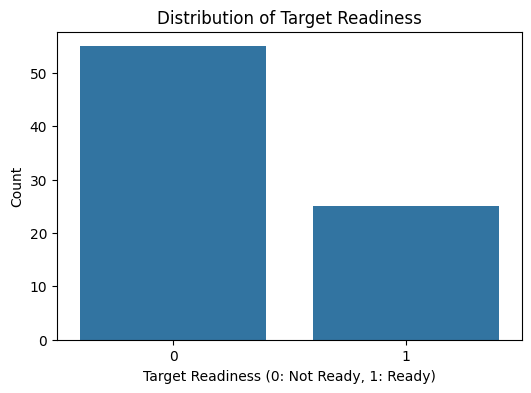

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='target_readiness', data=historical_df)
plt.title('Distribution of Target Readiness')
plt.xlabel('Target Readiness (0: Not Ready, 1: Ready)')
plt.ylabel('Count')
plt.show()

In [23]:
online_feature_df = pd.DataFrame(online_data)

X_online = online_feature_df[model_features]

final_prediction = int(
    model.predict(X_online)[0]
)

readiness_probability = float(
    model.predict_proba(X_online)[0][1]
)

print("Online features:")
display(X_online)

print("Student:", "S080")
print("Final prediction:", final_prediction)
print(
    "Readiness probability:",
    round(readiness_probability, 4)
)

if final_prediction == 1:
    print("Student is predicted to be industry-ready.")
else:
    print("Student may require additional training.")

Online features:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,python_gap,sql_gap,ml_gap,cloud_gap,communication_gap,average_skill_gap,industry_skill_average,projects_completed,internship_months,certification_count,industry_experience_months,project_experience_score,internship_experience_score,certification_score,industry_experience_score
0,1.0,-1.0,1.0,0.0,2.0,0.6,1.6,4,4,2,6,0.5,0.333333,0.5,0.166667


Student: S080
Final prediction: 0
Readiness probability: 0.0002
Student may require additional training.


In [24]:
!zip -r skill-gap-feast-project.zip . \
    -x "*.db" \
    -x "__pycache__/*" \
    -x "*.pyc"

  adding: feature_store.yaml (deflated 38%)
  adding: curriculum_industry_skill_gap.csv (deflated 73%)
  adding: data/ (stored 0%)
  adding: data/historical_features.parquet (deflated 70%)
  adding: data/skill_gap_model.joblib (deflated 40%)
  adding: data/skill_gap_features.parquet (deflated 70%)
  adding: prepare_data.py (deflated 71%)
  adding: feature_definitions.py (deflated 78%)


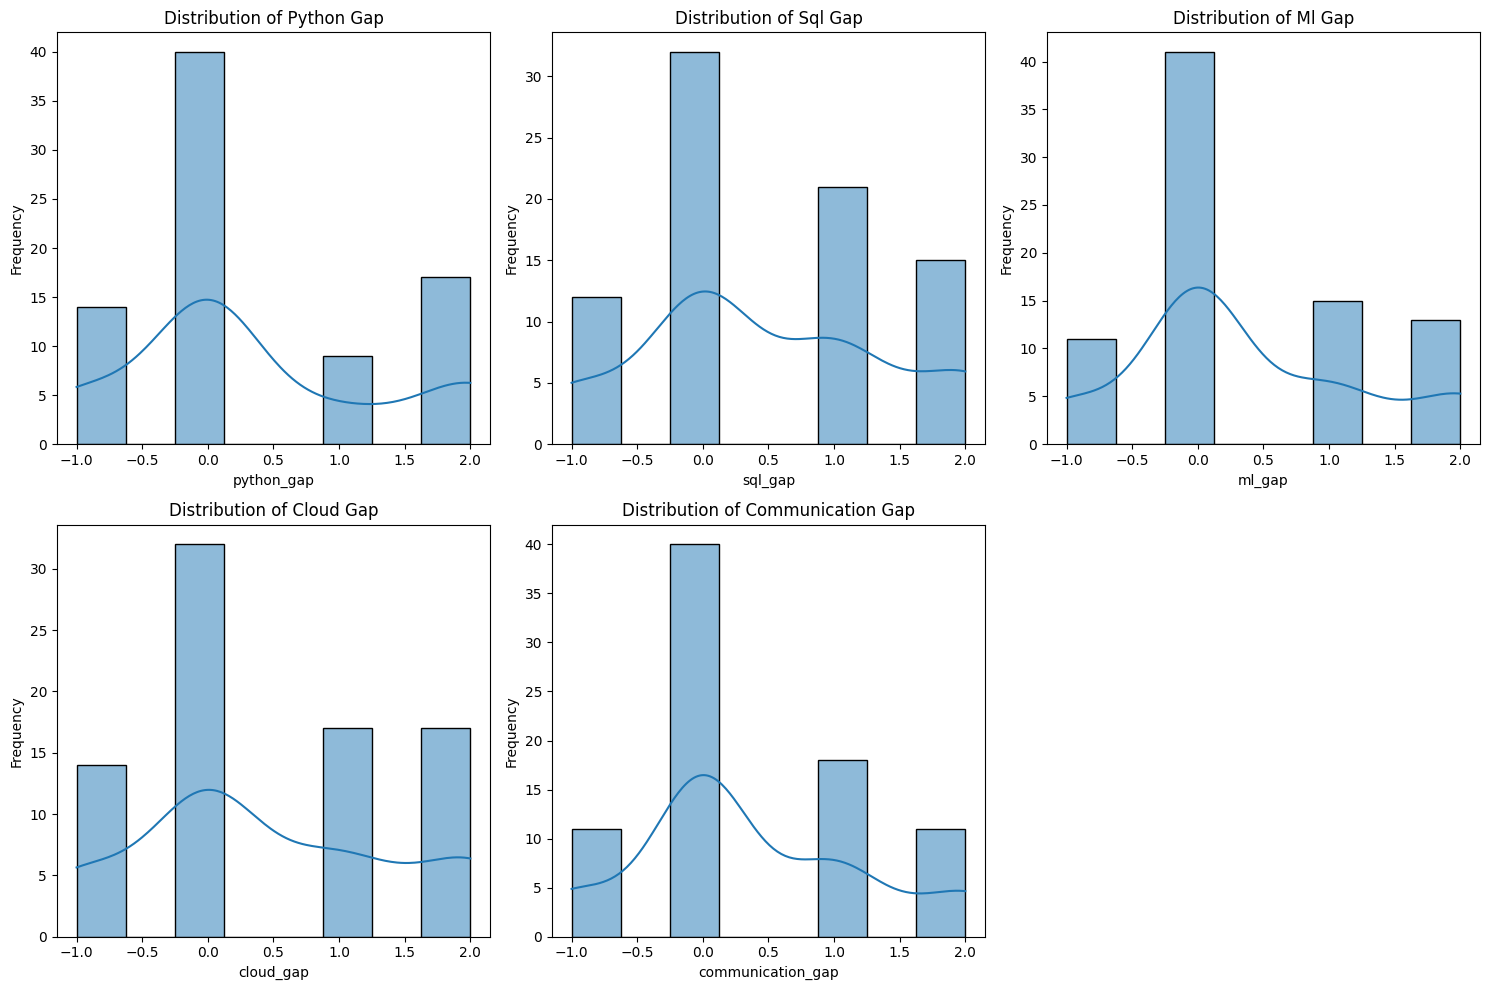

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

skill_gap_columns = [
    "python_gap",
    "sql_gap",
    "ml_gap",
    "cloud_gap",
    "communication_gap",
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(skill_gap_columns):
    plt.subplot(2, 3, i + 1)
    sns.histplot(historical_df[col], kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [27]:
from google.colab import files

files.download(
    "skill-gap-feast-project.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>